# DSCI 235 spr 2024 Assignment 2

**Instructions.** In this assignment we will answer some of the same questions from assignment 1.  The objective of this assignment is to practice Multi-Indexing, so **do not** use Boolean indexing / Boolean masks unless explicitly suggested you do so.  Also, do not use pandas functionality that we haven't covered in class unless explicitly suggested.  

In [50]:
import pandas as pd
import matplotlib.pyplot as plt


## Baby names in Colorado and Texas

In this assignment we will continue to analyze baby names.  This time the data will contain data collected in Colorado and Texas.
The data follows the same format as in the previous assignment:

```
CO,F,1910,Mary,193
CO,F,1910,Helen,112
CO,F,1910,Dorothy,87
CO,F,1910,Ruth,68
CO,F,1910,Margaret,67
...
TX,F,1910,Mary,895
TX,F,1910,Ruby,314
TX,F,1910,Annie,277
TX,F,1910,Willie,260
TX,F,1910,Ruth,252
...
```

The first column specifies the state (CO or TX), the second column is the gender (F/M), the third column is the year (1910-2018), and the last column is the number babies that were given that name during that year and state.

First, we will load the data straight into the Jupyter notebook:

#### Reading in the data

We'll use the pandas `read_csv` function to read the data:

In [51]:
# code for reading the data appropriately and creating a multi-index
names_flat = pd.read_csv('https://www.cs.colostate.edu/~asa/courses/dsci235/spr21/data/co_tx.txt', header=None, names=['state', 'gender', 'year', 'name', 'count'])
names_flat.head()

,state,gender,year,name,count
0,CO,F,1910,Mary,193
1,CO,F,1910,Helen,112
2,CO,F,1910,Dorothy,87
3,CO,F,1910,Ruth,68
4,CO,F,1910,Margaret,67


Next let's index it by state, gender, year, and name:

In [52]:
names=names_flat.set_index(['state','gender','year', 'name'])
names.head()

count
state gender year name           
CO    F      1910 Mary        193
                  Helen       112
                  Dorothy      87
                  Ruth         68
                  Margaret     67

You may choose to reindex the DataFrame depending on the needs of each question.

#### Most popular names

* What was the most popular female baby name in Colorado in 2018? (You can use `idxmax`).


In [53]:
names.loc[('CO', 'F', 2018), 'count'].idxmax()

'Olivia'

#### Increase in popularity

Which Colorado male name has shown the largest increase in popularity from 2017 to 2018?  Use the `subtract` method using a fill_value of 0 to prevent `NaN`s.

In [54]:
names_2017 = names.loc[('CO','M',2017), 'count']
names_2018 = names.loc[('CO','M',2018), 'count']


names_2018.subtract(names_2017, fill_value=0).idxmax()



'Nolan'

#### How many babies?

Compute how many babies were born in Colorado in 1945.

In [55]:

names.sort_index(inplace=True)
names.head()
idx = pd.IndexSlice
names.loc[idx['CO',:, 1945,:], 'count'].sum()



np.int64(21341)

#### Earliest occurrence of a name

What year did "Taylor" make its first appearance as a female name in Texas?  As a male name in Texas?  You can do this with or without using `reset_index` to change the index.

In [56]:
names.head()
names.reset_index(level = 'year', inplace=True)
names.sort_index(inplace=True)

In [ ]:


idx = pd.IndexSlice
Female_T = names.loc[idx['TX', 'F', 'Taylor'], 'year'].min()
Male_T = names.loc[idx['TX', 'M', 'Taylor'], 'year'].min()
print(f"Female Taylor(TEXAS): {Female_T}")
print(f"Male  Taylor(TEXAS): {Male_T}")           



Female Taylor(TEXAS): 1975
Male  Taylor(TEXAS): 1910


#### Combining data across Colorado and Texas

Create a new `DataFrame` that contains the sum of name counts from Colorado and Texas for each name for each year and gender.  The count column in this `DataFrame` will be the sum of the counts for a given baby name in Texas and Colorado for that give year in that gender.  Use the `add` method for this task.


In [ ]:
names=names_flat.set_index(['state','gender','year', 'name'])

Colorado = names.loc[idx['CO', :, :,:], ['count']]
Texas = names.loc[idx['TX', :, :,:], ['count']]

Colorado = Colorado.loc[idx['CO',:,:,:]]
Texas = Texas.loc[idx['TX',:,:,:]]

df = Colorado.add(Texas, fill_value=0)

df

count
gender year name         
F      1910 Abbie     7.0
            Ada      68.0
            Addie    40.0
            Adela    22.0
            Adele    15.0
...                   ...
M      2018 Zlatan    6.0
            Zuriel    8.0
            Zyaire   23.0
            Zyan      8.0
            Zyon     21.0

[351600 rows x 1 columns]

## Analyzing annual GDP

Next, we will analyze a dataset of annual Gross Domestic Product (GDP) collected from the 1960's across the world.  And remember - no Boolean indexing in this assignment!

In [59]:
gdp = pd.read_csv('http://cs.colostate.edu/~asa/courses/dsci235/spr21/data/worldstats.csv')
gdp.head()

,index,country,year,population,GDP
0,2271,Afghanistan,2015,32526562.0,1.919944e+10
1,2272,Afghanistan,2014,31627506.0,2.005019e+10
2,2273,Afghanistan,2013,30682500.0,2.004633e+10
3,2274,Afghanistan,2012,29726803.0,2.053654e+10
4,2275,Afghanistan,2011,28809167.0,1.793024e+10


Set the index to a MultiIndex that will help you answer the following questions:

* Create a DataFrame or Series that contains the GDP numbers for Pakistan between 2005 and 2010 (inclusive of the end points).

In [60]:
gdp.set_index(['country','index','year'], inplace=True)
gdp.head()

population           GDP
country     index year                          
Afghanistan 2271  2015  32526562.0  1.919944e+10
            2272  2014  31627506.0  2.005019e+10
            2273  2013  30682500.0  2.004633e+10
            2274  2012  29726803.0  2.053654e+10
            2275  2011  28809167.0  1.793024e+10

In [61]:
idx= pd.IndexSlice
gdp.loc[idx['Pakistan', :, 2005:2010], ['GDP']]

GDP
country  index year              
Pakistan 8402  2010  1.774069e+11
         8403  2009  1.681528e+11
         8404  2008  1.700778e+11
         8405  2007  1.523857e+11
         8406  2006  1.372641e+11
         8407  2005  1.095021e+11

* Compute the GDP per person, and add that to the data frame as a column labeled per_capita_gdp.

In [62]:
gdp['per_capita_gdp'] = gdp['GDP'] / gdp['population']
gdp.head()


population           GDP  per_capita_gdp
country     index year                                          
Afghanistan 2271  2015  32526562.0  1.919944e+10      590.269515
            2272  2014  31627506.0  2.005019e+10      633.947864
            2273  2013  30682500.0  2.004633e+10      653.347488
            2274  2012  29726803.0  2.053654e+10      690.842629
            2275  2011  28809167.0  1.793024e+10      622.379654

* Find the country that had the largest per-capita growth in GDP from 1990 to 2015.

In [63]:
per_capita_2015 = gdp.loc[idx[:, :, 2015], 'per_capita_gdp']
per_capita_1990 = gdp.loc[idx[:, :, 1990], 'per_capita_gdp']

per_capita_2015.subtract(per_capita_1990, fill_value=0).idxmax()



('Luxembourg', np.int64(7040), np.int64(2015))

* Plot the per_capita_gdp over time of three countries of your choice in a single graph.  Use a DataFrame's `plot` function for this.  The following [Stack Overflow post](https://stackoverflow.com/questions/45467320/plot-multiple-pandas-dataframes-in-one-graph) will help you in figuring out how to make pandas plot everything in the same graph.

In [64]:
gdp.reset_index()

,country,index,year,population,GDP,per_capita_gdp
0,Afghanistan,2271,2015,32526562.0,1.919944e+10,590.269515
1,Afghanistan,2272,2014,31627506.0,2.005019e+10,633.947864
2,Afghanistan,2273,2013,30682500.0,2.004633e+10,653.347488
3,Afghanistan,2274,2012,29726803.0,2.053654e+10,690.842629
4,Afghanistan,2275,2011,28809167.0,1.793024e+10,622.379654
...,...,...,...,...,...,...
8935,Zimbabwe,11206,1964,4279561.0,1.217138e+09,284.407209
8936,Zimbabwe,11207,1963,4140804.0,1.159512e+09,280.020909
8937,Zimbabwe,11208,1962,4006262.0,1.117602e+09,278.963682
8938,Zimbabwe,11209,1961,3876638.0,1.096647e+09,282.885996


In [65]:
gdp = gdp.reset_index()
gdp = gdp.set_index(['country','year']).sort_index()
gdp

index  population           GDP  per_capita_gdp
country     year                                                 
Afghanistan 1960   2307   8994793.0  5.377778e+08       59.787681
            1961   2306   9164945.0  5.488889e+08       59.890037
            1962   2305   9343772.0  5.466667e+08       58.505995
            1963   2304   9531555.0  7.511112e+08       78.802587
            1964   2303   9728645.0  8.000000e+08       82.231395
...                 ...         ...           ...             ...
Zimbabwe    2011  11159  14255592.0  1.095623e+10      768.556409
            2012  11158  14565482.0  1.239272e+10      850.827697
            2013  11157  14898092.0  1.349023e+10      905.500322
            2014  11156  15245855.0  1.419691e+10      931.198185
            2015  11155  15602751.0  1.389294e+10      890.416088

[8940 rows x 4 columns]

In [66]:
Afghanistan = gdp.loc[idx['Afghanistan', :], ['per_capita_gdp']]
Pakistan = gdp.loc[idx['Pakistan', :], ['per_capita_gdp']]
Zimbabwe = gdp.loc[idx['Zimbabwe', :], ['per_capita_gdp']]

In [67]:
Afghanistan.reset_index(inplace=True)
Afghanistan.set_index(['year'], inplace=True)

Pakistan.reset_index(inplace=True)
Pakistan.set_index(['year'], inplace=True)  

Zimbabwe.reset_index(inplace=True)
Zimbabwe.set_index(['year'], inplace=True)  

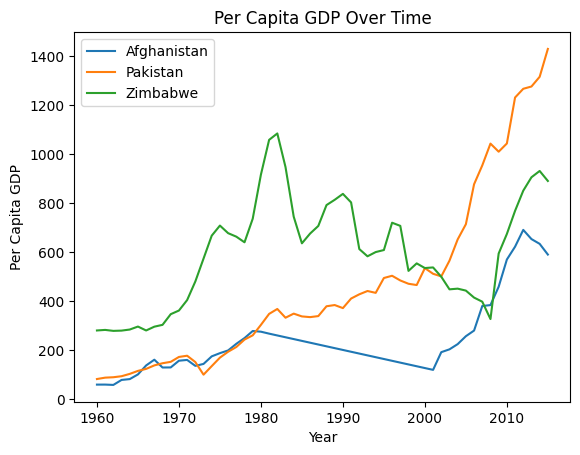

In [68]:
ax = Afghanistan.plot( label='Afghanistan')
Pakistan.plot(ax=ax, label='Pakistan')
Zimbabwe.plot(ax=ax, label='Zimbabwe')

ax.set_title('Per Capita GDP Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Per Capita GDP')
ax.legend(['Afghanistan', 'Pakistan', 'Zimbabwe'])


### Submission

Submit your assignment as a Jupyter notebook via Canvas.  

### Grading 

Here is what the grade sheet will look like for this assignment. 

```
Grading sheet for assignment 3

Baby names (60 pts)

  Most popular baby name in Colorado in 2018 (10 pts)
  Increase in popularity (10 pts)
  Unisex names (10 pts)
  How many babies in Colorado (10 pts)
  Earliest occurrence (10 pts)
  Combined data (10 pts)
  
GDP (40 pts)

  GDP of Pakistan (10 pts)
  GDP per person (10 pts)
  GDP growth (10 pts)
  GDP plot (10 pts)

```

Throughout the course, use of for loops is discouraged.  **Points will be taken off for using for loops unless explicitly allowed.**  pandas provides tools for accomplishing things without the need for Python loops.
